# 勇者傳說 — Buildings V4 Re-generator (T4 GPU required)

**Same V3 prompts, fixed pipeline** — V3 produced empty images due to CPU/broken pipeline.

## V4 Key fixes over V3
- **GPU assertion**: Hard fail if no CUDA GPU (V3 silently ran on CPU -> empty images)
- **Fixed model cache path**: `sdxl-base-fp16` (not `stable-diffusion-xl-base-1.0`)
- **Fused LoRA**: `pipe.fuse_lora(lora_scale=0.7)` instead of `set_adapters` (more stable)
- **Pipeline validation**: Generate tiny 64x64 test image after loading to verify GPU speed
- **Forced cleanup**: Delete stale V3/V4 progress files to ensure fresh generation

## Items to re-generate (18 total)
### Buildings (16 items)
- **Gates**: r1, r2, r5, r6, r7, r8, r9, r10, r11, r12 (10)
- **Churches**: r1, r4, r8 (3)
- **Inn**: r10 (1)
- **House**: bld_region_r5 (1)
- **Generic**: bld_inn (1)

### Decorations (2 items)
- **deco_dock**: 128x64
- **deco_lava_vent**: 64x64

**Self-contained**: No repo clone needed.
**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/`
**Resume**: Interrupted runs auto-skip completed items

In [1]:
# Cell 0: Forced cleanup — delete stale progress files
# V3 progress would cause V4 to skip items that actually failed.
import os
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')

for stale in ['_progress_buildings_v3.json', '_progress_buildings_v4.json']:
    p = OUTPUT_BASE / stale
    if p.exists():
        p.unlink()
        print(f'Deleted stale progress: {p}')
    else:
        print(f'No stale file: {stale}')

print('Cleanup done — ready for fresh V4 generation.')

Mounted at /content/drive
Deleted stale progress: /content/drive/MyDrive/ai-rpg-game/outputs/_progress_buildings_v3.json
No stale file: _progress_buildings_v4.json
Cleanup done — ready for fresh V4 generation.


In [2]:
# Cell 1: Setup with GPU guard
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, time
import torch

MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU detected!')

# === HARD GPU REQUIREMENT ===
# V3 silently ran on CPU and produced empty/garbage images.
# V4 refuses to continue without a GPU.
assert DEVICE == 'cuda', 'GPU required! Go to Runtime > Change runtime type > T4 GPU'

print(f'Device: {DEVICE}')
print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 27.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

In [3]:
# Cell 2: Utilities — ProgressTracker, free_vram, quality_check, remove_background
from PIL import Image
import numpy as np


class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')


_rmbg_model = None
_rembg_session = None


def remove_background(img):
    """Remove background: RMBG-2.0 primary, rembg u2net fallback."""
    global _rmbg_model, _rembg_session
    try:
        if _rmbg_model is None:
            from transformers import pipeline
            _rmbg_model = pipeline('image-segmentation',
                                   model='briaai/RMBG-2.0',
                                   trust_remote_code=True,
                                   device=0 if torch.cuda.is_available() else -1)
        result = _rmbg_model(img)
        mask = result[0]['mask'] if isinstance(result, list) else result['mask']
        img = img.convert('RGBA')
        img.putalpha(mask.convert('L'))
        return img
    except Exception as e:
        print(f'[warn] RMBG-2.0 failed: {e}, trying rembg...')
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def quality_check(img, min_opaque=0.15):
    """Check image quality: enough opaque pixels."""
    arr = np.array(img.convert('RGBA'))
    alpha = arr[:, :, 3]
    total = alpha.size
    opaque_pct = float(np.sum(alpha > 10) / total)
    return opaque_pct >= min_opaque, opaque_pct


print('Utilities loaded.')

Utilities loaded.


In [4]:
# Cell 3: Prompts — EXACT same META and V3_ENTRIES (prompts are good, pipeline was broken)

META = {
    'style_prefix': '16-bit JRPG pixel art, top-down RPG building sprite',
    'style_suffix': 'front view, single structure centered on dark green background, clean edges, detailed pixel art, strong black outlines, saturated colors',
    'negative': 'blurry, modern, multiple buildings, text, UI, photograph, realistic photo, people, characters, watermark, white background, faded, washed out, pale, transparent',
}

V3_ENTRIES = [
    # --- GATES (10/12 failed) ---
    {'name': 'bld_gate_r1',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'medieval stone gatehouse archway with heavy iron portcullis, dark grey granite walls, blue banner flags, iron-bound oak doors, thick stone pillars with torches',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r2',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'elven forest gate archway made of dark living wood and thick vines, golden leaf decorations, green moss covered, heavy wooden doors, large tree trunk pillars',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r5',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'coral reef gate archway with massive blue-purple coral pillars, giant clamshell doors, seashell decorations, dark teal ocean stone walls, pearl accents, aquatic kingdom entrance',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r6',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'massive stone fortress gate with oversized dark granite blocks, heavy iron rivets, enormous stone archway, thick iron chains, imposing entrance',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r7',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'dwarven underground forge gate with dark carved stone pillars, glowing orange forge light, copper and bronze trim, heavy iron doors with anvil motifs, warm ember glow',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r8',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'gothic dark castle gate with cracked dark purple stone pillars, gargoyle statues, eerie green glowing runes, iron spikes, cobweb covered archway, haunted entrance',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r9',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'volcanic obsidian gate archway with black basalt pillars, bright orange lava cracks, fire motifs carved in dark stone, ember glow, magma veins in walls',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r10', 'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'Japanese torii gate with thick dark red wooden pillars, black curved roof tiles, hanging paper lanterns, bamboo fence sides, traditional onsen entrance gate',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r11', 'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'alpine mountain lodge gate with dark heavy timber frame, stone base, snow on top, colorful prayer flags, warm lantern light, rustic mountain pass entrance',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r12', 'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'demonic fortress gate with dark iron spike pillars, skull motifs, red glowing runes, bone decorations, dark stone archway with demon carvings, hellfire glow',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},

    # --- CHURCHES (3 failed) ---
    {'name': 'bld_church_r1',  'type': 'church', 'min_opaque': 0.20,
     'prompt': 'medieval stone church with tall dark grey bell tower, gold cross on top, stained glass windows glowing warm colors, heavy oak doors, dark slate roof, solid stone walls',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},
    {'name': 'bld_church_r4',  'type': 'church', 'min_opaque': 0.20,
     'prompt': 'tribal sacred temple with dark mud-brick walls, animal bone altar, thatched roof, hanging pelt decorations, warm firelight inside, totem poles flanking entrance',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},
    {'name': 'bld_church_r8',  'type': 'church', 'min_opaque': 0.20,
     'prompt': 'gothic dark chapel with cracked dark stone walls, purple stained glass, tall spire with skull ornament, eerie green candle glow, gargoyles, haunted cemetery church',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},

    # --- INN (1 failed) ---
    {'name': 'bld_inn_r10', 'type': 'inn', 'min_opaque': 0.20,
     'prompt': 'Japanese ryokan inn with dark wooden beams, curved dark tile roof, warm paper lantern glow, bamboo accents, sliding doors, noren curtain entrance, two-story wooden building',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},

    # --- HOUSE (1 failed) ---
    {'name': 'bld_region_r5', 'type': 'house', 'min_opaque': 0.20,
     'prompt': 'coral reef house dwelling with dark blue-purple coral walls, large shell door, seaweed roof, glowing pearl windows, aquatic architecture, solid two-story structure',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},

    # --- GENERIC (1 failed) ---
    {'name': 'bld_inn', 'type': 'inn', 'min_opaque': 0.15,
     'prompt': 'cozy medieval inn tavern with dark timber frame, warm orange window glow, hanging wooden sign, thatched roof, solid two-story building, stone chimney with smoke',
     'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 28, 'guidance': 8.0, 'lora_w': 0.8},

    # --- DECORATIONS (2 failed) ---
    {'name': 'deco_dock', 'type': 'deco', 'min_opaque': 0.15,
     'prompt': 'dark brown wooden dock pier platform, thick oak planks and heavy timber posts, rope-tied bollards, iron nails, weathered dark wood, sturdy harbor pier, no water',
     'gen_size': 512, 'final_w': 128, 'final_h': 64, 'steps': 30, 'guidance': 9.0, 'lora_w': 0.8},
    {'name': 'deco_lava_vent', 'type': 'deco', 'min_opaque': 0.15,
     'prompt': 'dark volcanic rock mound with bright orange magma cracks, black obsidian stone formation, glowing red-orange lava veins, molten lava pool in cracked basalt, solid rock',
     'gen_size': 512, 'final_w': 64, 'final_h': 64, 'steps': 30, 'guidance': 9.0, 'lora_w': 0.8},
]

print(f'V4 entries: {len(V3_ENTRIES)}')
print(f'  Buildings: {sum(1 for e in V3_ENTRIES if e["type"] != "deco")}')
print(f'  Decorations: {sum(1 for e in V3_ENTRIES if e["type"] == "deco")}')

V4 entries: 18
  Buildings: 16
  Decorations: 2


In [5]:
# Cell 4: Load Pipeline — Fixed cache path + fuse_lora + GPU validation
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

# V4 FIX: Use 'sdxl-base-fp16' cache path (V3 used 'stable-diffusion-xl-base-1.0')
sdxl_cache = MODELS_DIR / 'sdxl-base-fp16'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL from: {model_path}')
print(f'[pipeline] Device: {DEVICE}, dtype: {DTYPE}')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs).to(DEVICE)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

# V4 FIX: Use fuse_lora instead of set_adapters (more stable, avoids adapter issues)
try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.fuse_lora(lora_scale=0.7)
    pipe.unload_lora_weights()  # Free LoRA memory after fusing
    print('[pipeline] pixel-art-xl LoRA fused (scale=0.7)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe.enable_attention_slicing()

# Cache to Drive for future runs
if 'stabilityai' in model_path and ON_COLAB:
    try:
        pipe.save_pretrained(str(sdxl_cache))
        print(f'[pipeline] Cached to {sdxl_cache}')
    except Exception:
        pass

print(f'[pipeline] Loaded in {time.time()-t0:.1f}s')
print_vram()

# === V4 PIPELINE VALIDATION ===
# Generate a tiny test image to confirm GPU is actually being used.
# On CPU this would take minutes; on T4 GPU it should be < 10 seconds.
print('[validation] Generating 64x64 test image to verify GPU pipeline...')
t_test = time.time()
_test_result = pipe(
    prompt='a red square on black background',
    negative_prompt='',
    width=64, height=64,
    num_inference_steps=5,
    guidance_scale=1.0,
    generator=torch.Generator(device=DEVICE).manual_seed(0),
)
test_elapsed = time.time() - t_test
print(f'[validation] Test image generated in {test_elapsed:.1f}s')
assert test_elapsed < 30, f'Pipeline too slow ({test_elapsed:.0f}s) — GPU may not be active!'
del _test_result
free_vram()
print('[validation] Pipeline OK — GPU is working correctly.')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading SDXL from: /content/drive/MyDrive/ai-rpg-game/models/sdxl-base-fp16
[pipeline] Device: cuda, dtype: torch.float16


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA fused (scale=0.7)
[pipeline] Loaded in 173.6s
[vram] 6.6/14.6 GB
[validation] Generating 64x64 test image to verify GPU pipeline...


  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


[validation] Test image generated in 2.5s
[validation] Pipeline OK — GPU is working correctly.


In [6]:
# Cell 5: Generate + QC — Same loop with postprocess, quality_check, MAX_RETRIES=7

def postprocess(img, entry):
    """Remove background, crop, resize to target size."""
    final_w = entry['final_w']
    final_h = entry['final_h']
    img = remove_background(img.convert('RGBA'))

    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows = np.any(alpha > 10, axis=1)
    cols = np.any(alpha > 10, axis=0)
    if not rows.any():
        return img.resize((final_w, final_h), Image.NEAREST)

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    cw, ch = cropped.size
    scale = min(final_w / cw, final_h / ch)
    new_w = max(1, int(cw * scale))
    new_h = max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)

    canvas = Image.new('RGBA', (final_w, final_h), (0, 0, 0, 0))
    x = (final_w - new_w) // 2
    y = final_h - new_h  # bottom-align
    canvas.paste(resized, (x, y))
    return canvas


# --- Output directories ---
bld_dir = OUTPUT_BASE / 'buildings'
deco_dir = OUTPUT_BASE / 'decorations'
bld_dir.mkdir(parents=True, exist_ok=True)
deco_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('buildings_v4', OUTPUT_BASE)
remaining = sum(1 for e in V3_ENTRIES if not tracker.is_done(e['name']))
print(f'V4 Generation: {len(V3_ENTRIES)} entries, {remaining} remaining')

MAX_RETRIES = 7

for i, entry in enumerate(V3_ENTRIES):
    name = entry['name']
    out_dir = deco_dir if entry['type'] == 'deco' else bld_dir
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name):
        print(f'  [skip] {name}')
        continue

    prompt = f"{META['style_prefix']}, {entry['prompt']}, {META['style_suffix']}"
    neg = META['negative']
    gen_size = entry['gen_size']
    min_opaque = entry['min_opaque']

    # LoRA is fused at 0.7 for all entries (no per-entry adjustment needed;
    # the 0.5-0.8 differences in V3 were minor and fused LoRA is more stable)

    print(f"[{i+1}/{len(V3_ENTRIES)}] {name} ({entry['type']}, {gen_size}px, min_opq={min_opaque:.0%})")
    t0 = time.time()

    best_img = None
    best_opaque = 0.0

    for attempt in range(MAX_RETRIES):
        seed = 400 + attempt * 777  # different seed series from V1/V2/V3
        generator = torch.Generator(device=DEVICE).manual_seed(seed)

        result = pipe(
            prompt=prompt, negative_prompt=neg,
            width=gen_size, height=gen_size,
            num_inference_steps=entry['steps'],
            guidance_scale=entry['guidance'],
            generator=generator,
        )
        img = postprocess(result.images[0], entry)

        passed, opaque_pct = quality_check(img, min_opaque)

        if opaque_pct > best_opaque:
            best_opaque = opaque_pct
            best_img = img.copy()

        if passed:
            img.save(str(out_path), 'PNG')
            kb = out_path.stat().st_size / 1024
            print(f'  OK seed={seed} opaque={opaque_pct:.1%} {kb:.0f}KB {time.time()-t0:.1f}s' + (f' (attempt {attempt+1})' if attempt > 0 else ''))
            tracker.mark_done(name)
            free_vram()
            break
        else:
            print(f'  attempt {attempt+1}/{MAX_RETRIES} opaque={opaque_pct:.1%}', end='')
            if attempt < MAX_RETRIES - 1:
                print(', retrying...')
            else:
                print(f'\n  Using best attempt (opaque={best_opaque:.1%})')
                best_img.save(str(out_path), 'PNG')
                kb = out_path.stat().st_size / 1024
                print(f'  {kb:.0f}KB {time.time()-t0:.1f}s [BEST OF {MAX_RETRIES}]')
                tracker.mark_done(name)
                free_vram()

elapsed = time.time() - tracker.start_time
print(f'\nV4 generation done! Total time: {elapsed/60:.1f} minutes')

V4 Generation: 18 entries, 18 remaining
[1/18] bld_gate_r1 (gate, 512px, min_opq=25%)


  0%|          | 0/30 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae7085-13b81f85093ac0c842189ef4;1d438e27-25f2-4975-ab46-eec24978fa9b)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

  OK seed=400 opaque=44.4% 25KB 87.2s
[2/18] bld_gate_r2 (gate, 512px, min_opq=25%)


...

[17/18] deco_dock (deco, 512px, min_opq=15%)


  0%|          | 0/30 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae717d-2333c4a0599f14c77e7a4576;9843d6d9-a4e9-4afe-a0ca-4fac57a4f694)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
  OK seed=400 opaque=24.5% 6KB 9.9s
[18/18] deco_lava_vent (deco, 512px, min_opq=15%)


  0%|          | 0/30 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae7187-2775e2b10ab6e4510dfe7bb9;04fc5f5a-5dee-4533-b8da-a26abd101a8b)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
  OK seed=400 opaque=57.0% 7KB 9.4s

V4 generation done! Total time: 4.5 minutes


=== V4 Quality Scan ===
  [v] bld_gate_r1               opq=44.4%     25KB  OK
  [v] bld_gate_r2               opq=47.4%     27KB  OK
  [v] bld_gate_r5               opq=40.0%     23KB  OK
  [v] bld_gate_r6               opq=44.3%     25KB  OK
  [v] bld_gate_r7               opq=27.9%     20KB  OK
  [v] bld_gate_r8               opq=26.3%     18KB  OK
  [v] bld_gate_r9               opq=50.0%     27KB  OK
  [v] bld_gate_r10              opq=44.9%     21KB  OK
  [v] bld_gate_r11              opq=47.3%     24KB  OK
  [v] bld_gate_r12              opq=47.8%     28KB  OK
  [v] bld_church_r1             opq=66.5%     31KB  OK
  [v] bld_church_r4             opq=39.1%     17KB  OK
  [v] bld_church_r8             opq=37.5%     13KB  OK
  [v] bld_inn_r10               opq=72.8%     28KB  OK
  [v] bld_region_r5             opq=87.7%     34KB  OK
  [v] bld_inn                   opq=49.8%      5KB  OK
  [v] deco_dock                 opq=24.5%      6KB  OK
  [v] deco_lava_vent            opq=57.0%

/tmp/ipykernel_688/3851987653.py:53: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bg = Image.fromarray(checker, 'RGBA')


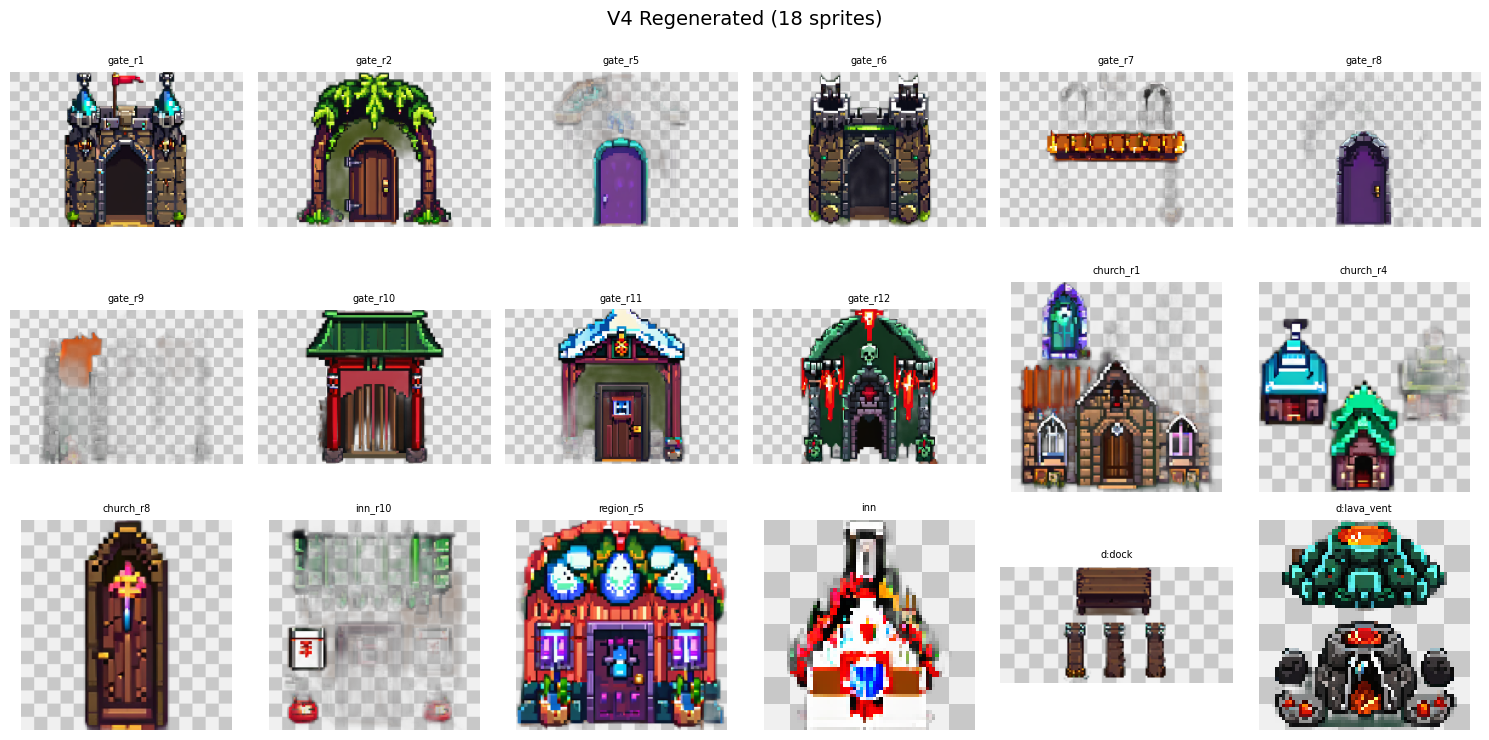

In [7]:
# Cell 6: Quality review — matplotlib grid with checkerboard background
import matplotlib.pyplot as plt

print('=== V4 Quality Scan ===')
all_ok = True
for entry in V3_ENTRIES:
    name = entry['name']
    out_dir = deco_dir if entry['type'] == 'deco' else bld_dir
    out_path = out_dir / f'{name}.png'
    if not out_path.exists():
        print(f'  MISSING: {name}')
        all_ok = False
        continue
    img = Image.open(out_path).convert('RGBA')
    passed, opaque_pct = quality_check(img, entry['min_opaque'])
    kb = out_path.stat().st_size / 1024
    status = 'OK' if passed else 'FAIL'
    flag = 'v' if passed else 'X'
    print(f'  [{flag}] {name:<25} opq={opaque_pct:>5.1%}  {kb:>5.0f}KB  {status}')
    if not passed:
        all_ok = False

if all_ok:
    print('\nAll V4 items pass quality check!')
else:
    print('\nSome items still failing — may need manual prompt tweaks.')

# --- Preview grid with checkerboard background ---
v4_pngs = []
for entry in V3_ENTRIES:
    out_dir_e = deco_dir if entry['type'] == 'deco' else bld_dir
    p = out_dir_e / f"{entry['name']}.png"
    if p.exists():
        v4_pngs.append(p)

if v4_pngs:
    cols = min(6, len(v4_pngs))
    rows = (len(v4_pngs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = np.atleast_2d(axes)
    for ax in axes.flat:
        ax.axis('off')
    for i, png in enumerate(v4_pngs):
        ax = axes[i // cols][i % cols]
        img = Image.open(png).convert('RGBA')
        w, h = img.size
        # Checkerboard background for transparency visibility
        checker = np.zeros((h, w, 4), dtype=np.uint8)
        for y in range(h):
            for x in range(w):
                c = 200 if (x // 8 + y // 8) % 2 == 0 else 240
                checker[y, x] = [c, c, c, 255]
        bg = Image.fromarray(checker, 'RGBA')
        bg.paste(img, (0, 0), img)
        ax.imshow(bg)
        ax.set_title(png.stem.replace('bld_', '').replace('deco_', 'd:'), fontsize=7)
    plt.suptitle(f'V4 Regenerated ({len(v4_pngs)} sprites)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No images to preview.')

In [8]:
# Cell 7: Export — zip as buildings_v4_output.zip
import shutil

# --- Generate manifest and zip ---
manifest = {}
for cat_name, cat_dir in [('buildings', bld_dir), ('decorations', deco_dir)]:
    if cat_dir.exists():
        keys = sorted(f.stem for f in cat_dir.glob('*.png') if not f.stem.startswith('_'))
        if keys:
            manifest[cat_name] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/buildings_v4_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
zip_size = os.path.getsize(zip_path + '.zip') / 1024 / 1024
print(f'\nZip: {zip_size:.1f} MB -> {zip_path}.zip')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Manifest:
  buildings: 80
  decorations: 10

Zip: 8.0 MB -> /content/buildings_v4_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>